In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [8]:
ss = pd.read_csv("solar_system.csv", index_col=0)
print("Shape of dataset:", ss.shape)
rows, cols = ss.shape
print("Number of rows:", rows)
print("Number of columns:", cols)

print("\nFirst five rows:")
print(ss.head())

print("\nLast five rows:")
print(ss.tail())

print("\nColumn names:")
print(ss.columns)

print("\nRow names:")
print(ss.index)

Shape of dataset: (20, 10)
Number of rows: 20
Number of columns: 10

First five rows:
                       Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
Attribute                                                                    
Mass (10^24kg)           0.330   4.87   5.97  0.073  0.642    1898     568   
Diameter (km)             4879  12104  12756   3475   6792  142984  120536   
Density (kg/m^3)          5429   5243   5514   3340   3934    1326     687   
Gravity (m/s^2)            3.7    8.9    9.8    1.6    3.7    23.1     9.0   
Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

                       Uranus Neptune   Pluto  
Attribute                                      
Mass (10^24kg)           86.8     102  0.0130  
Diameter (km)           51118   49528    2376  
Density (kg/m^3)         1270    1638    1850  
Gravity (m/s^2)           8.7    11.0     0.7  
Escape Velocity (km/s)   21.3    23.5     1.3  

Last five rows:
              

In [10]:
orbital_period = ss.iloc[0].astype(float)   # row 0: Orbital period
perihelion     = ss.iloc[1].astype(float)   # row 1: Perihelion
aphelion       = ss.iloc[2].astype(float)   # row 2: Aphelion

# Perihelion is the distance from a planet to the Sun when the planet is closest to the Sun in its orbit
# Aphelion is the distance from a planet to the Sun when it is farthest from the Sun in its orbit.
# Semi - major axis is half of the longest diameter of the elliptical orbit.

In [11]:
semi_major_axis = (perihelion + aphelion) / 2
semi_major_axis.name = "Semi-major axis"
ss = pd.concat([ss, semi_major_axis.to_frame().T])
print("New shape of DataFrame:", ss.shape)


New shape of DataFrame: (21, 10)


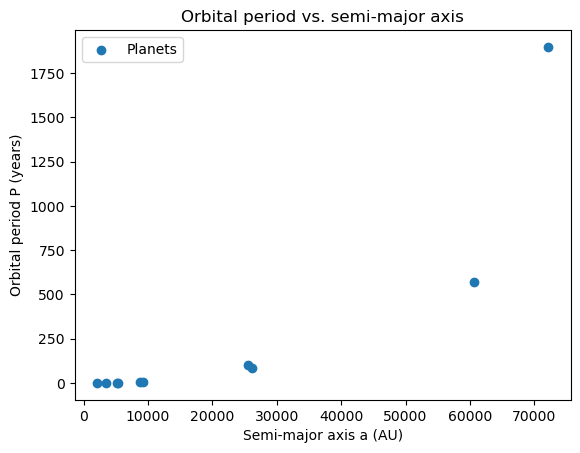

In [12]:
a = semi_major_axis.values
P = orbital_period.values

plt.scatter(a, P, label="Planets")
plt.xlabel("Semi-major axis a (AU)")
plt.ylabel("Orbital period P (years)")
plt.title("Orbital period vs. semi-major axis")
plt.legend()
plt.show()

In [ ]:
def keplers_third_law(a, m):
    return m * a**1.5
popt, pcov = curve_fit(keplers_third_law, a, P, p0=[1.0])
m_fit = popt[0]
print(f"Best-fit m = {m_fit:.2f}")
print(f"Fitted model: P = {m_fit:.2f} * a^(3/2)")